In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
df = pd.read_csv('cricket_performance.csv')

In [ ]:
X = df[['Pitch_Hardness', 'Humidity', 'Bowling_Aggression']]
y = df['Performance_Rating']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("\nTraining the 3D SVM Model...")
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train_scaled, y_train)


Training the 3D SVM Model...


SVC()

In [ ]:
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 80.00%

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.90      0.90        39
         Low       0.79      0.79      0.79        29
      Medium       0.69      0.69      0.69        32

    accuracy                           0.80       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.80      0.80      0.80       100



In [ ]:
print("\nGenerating 2D SVM Decision Boundary Image...")



Generating 2D SVM Decision Boundary Image...


In [ ]:
X_2d = df[['Humidity', 'Bowling_Aggression']]
y_2d = df['Performance_Rating']

In [ ]:
le = LabelEncoder()
y_2d_encoded = le.fit_transform(y_2d)

In [ ]:
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d_encoded, test_size=0.2, random_state=42)
scaler_2d = StandardScaler()
X_train_scaled_2d = scaler_2d.fit_transform(X_train_2d)


In [ ]:
svm_2d = SVC(kernel="rbf", C=1.0)
svm_2d.fit(X_train_scaled_2d, y_train_2d)

SVC()

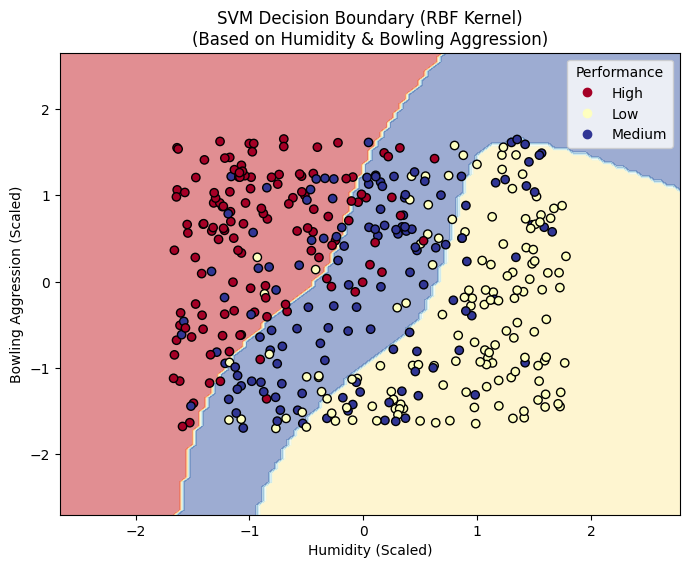

In [ ]:
 # 5. Draw the background boundaries and overlay the points
fig, ax = plt.subplots(figsize=(8, 6))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_2d, X_train_scaled_2d, response_method="predict",
    alpha=0.5, cmap=plt.cm.RdYlBu, ax=ax
)

# Plot the actual training points on top
scatter = ax.scatter(X_train_scaled_2d[:, 0], X_train_scaled_2d[:, 1], c=y_train_2d, edgecolor="k", cmap=plt.cm.RdYlBu)

# Add a legend to explain the colors
handles, _ = scatter.legend_elements()
ax.legend(handles, le.classes_, title="Performance")

ax.set_title("SVM Decision Boundary (RBF Kernel)\n(Based on Humidity & Bowling Aggression)")
ax.set_xlabel("Humidity (Scaled)")
ax.set_ylabel("Bowling Aggression (Scaled)")
plt.show()